In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
#Load the data
X_train=pd.read_csv('/content/drive/MyDrive/Data/X_train.csv')
X_test=pd.read_csv('/content/drive/MyDrive/Data/X_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/Data/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Data/y_test.csv')

In [ ]:
import joblib
model_path='/content/drive/MyDrive/(add your folder name)/Models'
lr_model= joblib.load(f"{model_path}/logistic_regression.pkl")
dt_model= joblib.load(f"{model_path}/decision_tree.pkl")
rf_model= joblib.load(f"{model_path}/random_forest.pkl")
xgb_model = joblib.load(f"{model_path}/xgboost_tuned.pkl")

In [ ]:
#Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
    confusion_matrix, roc_curve,precision_recall_curve)

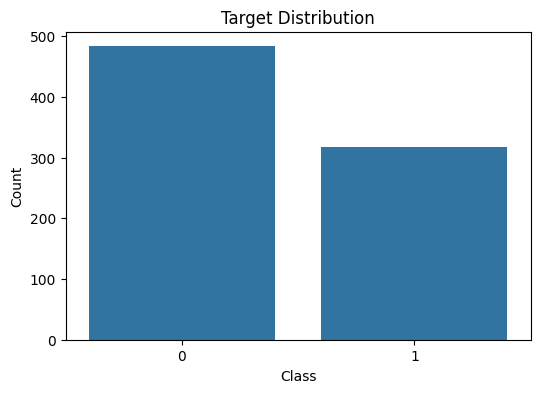

In [ ]:
#Target distribution
y_series = pd.Series(y_train.iloc[:, 0])
plt.figure(figsize=(6,4))
sns.countplot(x=y_series)
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
plt.savefig("/content/drive/MyDrive/Visualizations/target_distribution.png")
plt.close()

Linear regression
Accuracy: 0.72
Precision: 0.676923076923077
Recall: 0.5569620253164557
F1 Score: 0.6111111111111112
AUC-ROC: 0.7932838162987761


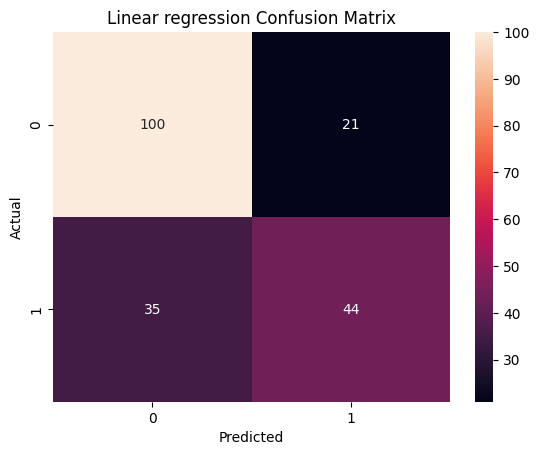

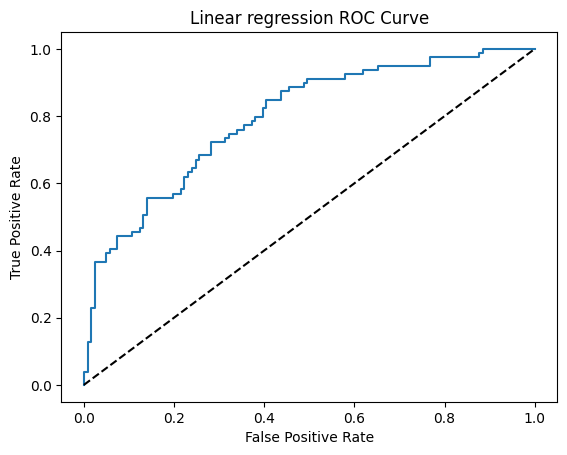

In [ ]:
#Predictions For Linear regression
print('Linear regression')
y_pred= lr_model.predict(X_test)
y_pred_proba= lr_model.predict_proba(X_test)[:, 1]
#Metrics
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("AUC-ROC:",roc_auc_score(y_test, y_pred_proba))
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Linear regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('/content/drive/MyDrive/Visualizations/model_cm.png')
plt.show()
#ROC Curve
fpr,tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear regression ROC Curve")
plt.savefig('/content/drive/MyDrive/Visualizations/roc_lr.png')
plt.show()

DECISION TREE
Decision Tree Performance:
Accuracy: 0.7900
Precision: 0.7284
Recall: 0.7468
F1 Score: 0.7375
AUC-ROC: 0.7825


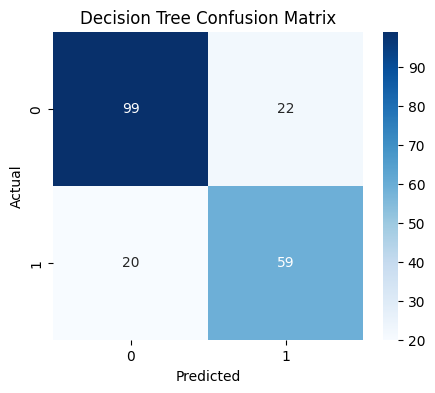

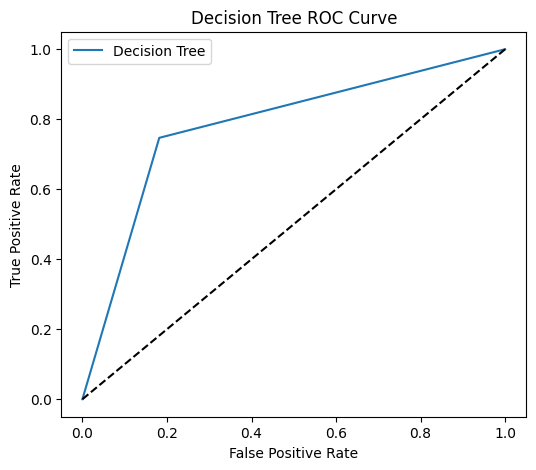

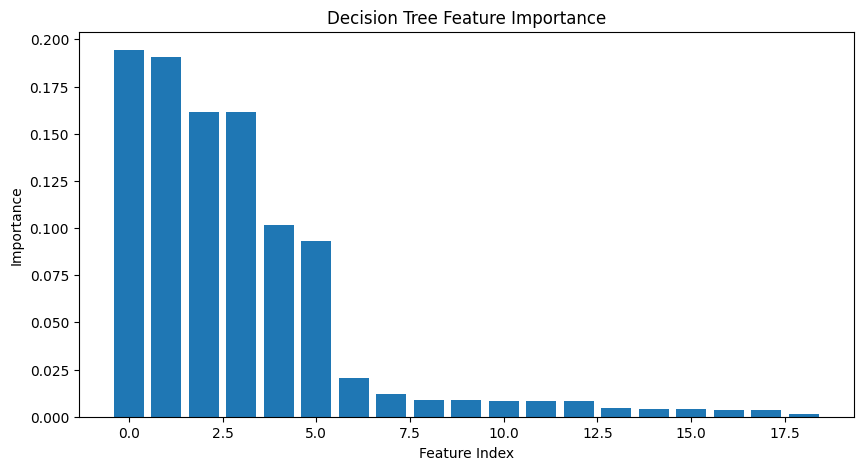

In [ ]:
#Predictions for DECISION TREE
print('DECISION TREE')
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]  # probability for ROC

#Metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")
print(f"AUC-ROC: {auc_dt:.4f}")

#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("/content/drive/MyDrive/Visualizations/dt_cm.png")
plt.show()
plt.close()

#ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.savefig("/content/drive/MyDrive/Visualizations/dt_roc.png")
plt.show()
plt.close()

#Feature Importance

importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.title("Decision Tree Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.savefig("/content/drive/MyDrive/Visualizations/dt_feature_importance.png")
plt.show()
plt.close()

Random Forest Performance:
Accuracy: 0.8100
Precision: 0.8060
Recall: 0.6835
F1 Score: 0.7397
AUC-ROC: 0.9208


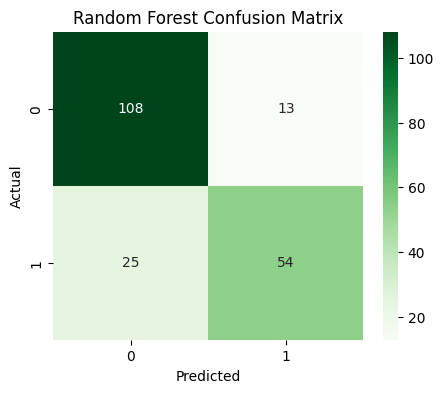

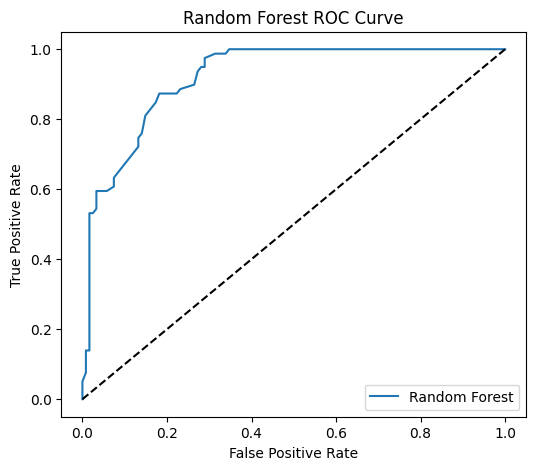

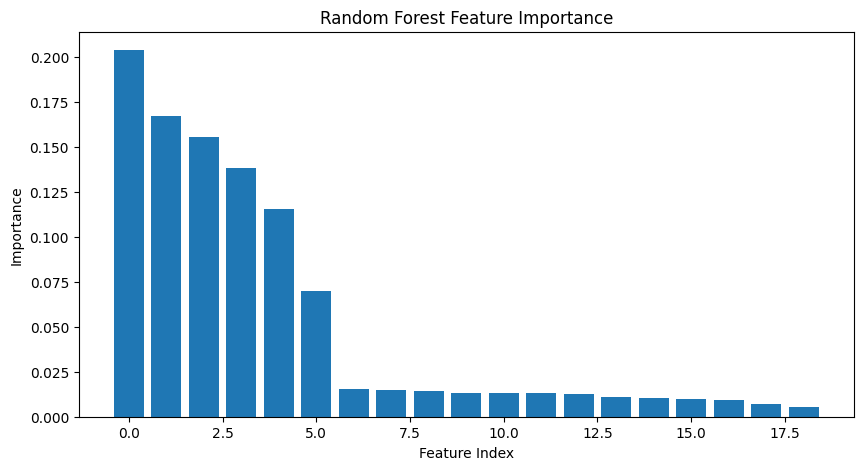

In [ ]:
#Predictions For RANDOM FOREST
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # probability for ROC

#Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")

#Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("/content/drive/MyDrive/Visualizations/rf_cm.png")
plt.show()
plt.close()

#ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.savefig("/content/drive/MyDrive/Visualizations/rf_roc.png")
plt.show()
plt.close()

#Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.savefig("/content/drive/MyDrive/Visualizations/rf_feature_importance.png")
plt.show()
plt.close()

XGBoost Performance:
Accuracy: 0.8600
Precision: 0.8493
Recall: 0.7848
F1 Score: 0.8158
AUC-ROC: 0.9574


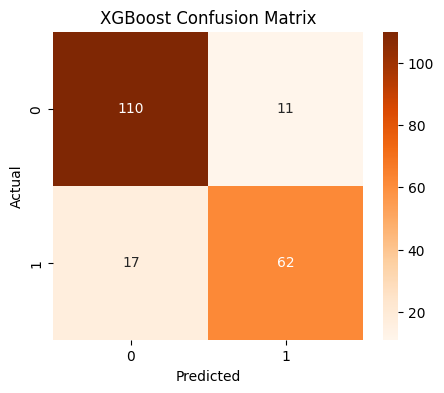

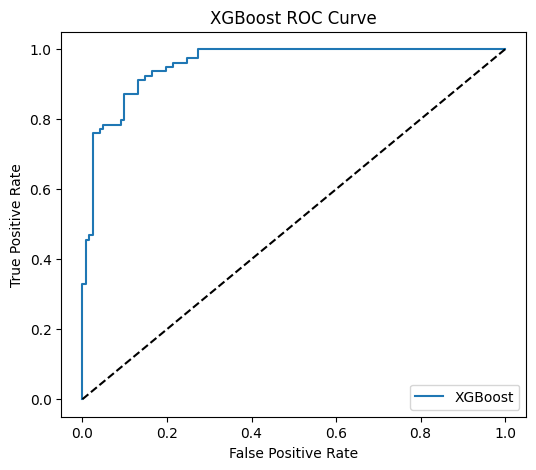

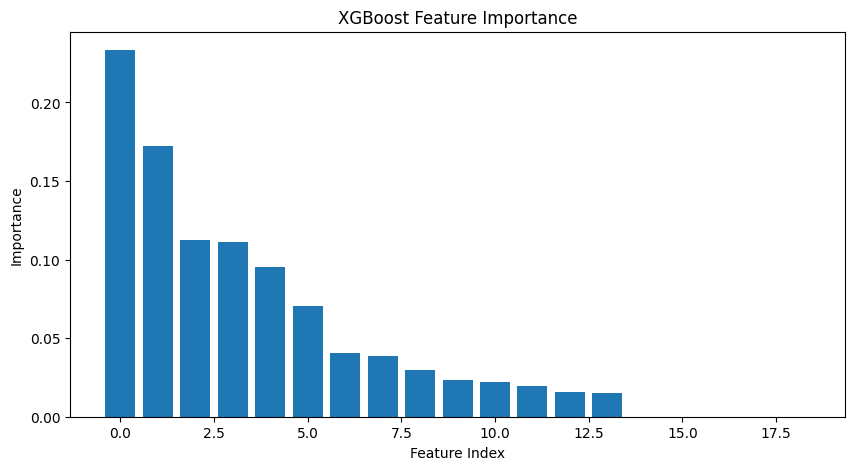

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]  # probability for ROC

# ===== Metrics =====
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"AUC-ROC: {auc_xgb:.4f}")

# ===== Confusion Matrix =====
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("/content/drive/MyDrive/Visualizations/xgb_cm.png")
plt.show()
plt.close()

#ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.savefig("/content/drive/MyDrive/Visualizations/xgboost_roc.png")
plt.show()
plt.close()

#Feature Importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.title("XGBoost Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.savefig("/content/drive/MyDrive/Visualizations/xgboost_feature_importance.png")
plt.show()
plt.close()

## 3.3 Business Interpretation

### Which Metric Matters Most and Why?
**Recall** is the most important metric for this credit risk problem.  

In credit risk, the goal is to correctly identify as many **bad-risk customers (defaulters)** as possible. Missing a defaulter (False Negative) means the bank approves a loan for someone who will not repay — this directly causes financial loss.  

Missing a good customer (False Positive) is less harmful — the bank just rejects a customer who could have repaid, losing potential profit but not actual money.  

**Conclusion:** Minimizing False Negatives = maximizing **Recall** is the top priority.

---

### Cost of False Positives vs False Negatives

| Description      | Cost |
|-----------------|------|
| False Positive   | Predicted bad risk, actually good → Low — bank loses potential interest income by rejecting a good customer |
| False Negative   | Predicted good risk, actually bad → High — bank loses the entire loan amount when customer defaults |

False Negatives are significantly more costly than False Positives in credit risk. A single loan default can cost the bank 10–20x more than the profit lost from rejecting a good customer.

---

### Recommended Recall Threshold for Production
A **recall threshold ≥ 75%** is recommended for production deployment because:  

- It ensures at least 3 out of 4 defaulters are correctly identified  
- It balances catching defaulters without rejecting too many good customers  
- The tuned **XGBoost model** achieves a recall of **0.785**, which meets this threshold ✅  
- Going higher (e.g., 90%+) would reject too many good customers and hurt business revenue

---

## 3.4 Model Selection & Deployment

### Recommended Model — Tuned XGBoost
Tuned XGBoost is recommended for production based on the following justification:

| Criteria          | Tuned XGBoost | Justification |
|-----------------|----------------|---------------|
| Accuracy         | 0.860          | Highest among all models |
| Recall           | 0.785          | Meets the ≥75% threshold for defaults |
| Precision        | 0.849          | Low false positive rate |
| F1 Score         | 0.816          | Best overall balance |
| Interpretability | Medium         | SHAP values can explain predictions for regulatory compliance |
| Inference Speed  | Fast           | Predicts in milliseconds, suitable for real-time use |
| Maintenance      | Medium         | Requires periodic retraining but well supported by MLflow |

---

### Deployment Plan

1. **Infrastructure**  
   - Deploy model on Google Cloud / AWS using Docker  
   - Serve model via **Flask** or **FastAPI** REST API  
   - Store trained model (`model.pkl`) in cloud storage (GCS / S3)  
   - Load model at API startup using `mlflow.sklearn.load_model()`

2. **API Design**  
   - **POST /predict**  
     - **Input:** JSON with customer features  
       ```json
       { "age": 35, "credit_amount": 10000, "duration": 24, "purpose": "car", "saving_accounts": "moderate", ... }
       ```  
     - **Output:**  
       ```json
       { "risk_prediction": 1, "probability": 0.85, "risk_label": "bad" }
       ```

3. **Input Validation**  
   - Check required fields are present  
   - Validate data types and value ranges (e.g., age 18–100, duration 1–72 months)  
   - Return clear error messages for invalid inputs  

4. **Performance Monitoring**  
   - Log every prediction with timestamp, inputs, and outputs  
   - Monitor Accuracy, Precision, Recall, F1 weekly  
   - Set alerts if Accuracy < 0.80 or Recall < 0.75  
   - Visualize trends using Grafana / MLflow dashboards  

5. **Data Drift Detection**  
   - Monitor feature distributions weekly  
   - Compare live vs training data distributions  
   - Use statistical tests (KS test) to detect drift  
   - Trigger retraining if significant drift occurs  

6. **Retraining Strategy**  
   - Retrain every 3–6 months with new loan data  
   - Retrain immediately if Recall drops below 0.75  
   - Version all retrained models with MLflow  
   - Validate on holdout test set before production replacement  

7. **A/B Testing Approach**  
   - Run old and new models on live traffic  
   - Split traffic (80% old, 20% new)  
   - Compare Recall, Precision, F1 over 2–4 weeks  
   - Switch fully to new model only if it consistently outperforms old  
   - Rollback immediately if Recall < 0.75  

**Summary:**  
Tuned **XGBoost** is the best model for production with **highest accuracy (86%)**, **recall above 75%**, **fast inference speed**, and full **MLflow tracking** for maintenance and regulatory compliance.